# E-Commerce Sales Analysis & Demand Prediction

**Internship Project — Data Science**
**Author:** Nivash | B.Tech CSE (AI & ML), VIT Chennai

## Objective
Analyze historical e-commerce sales data and build machine learning models
to predict future product demand, supporting data-driven inventory
optimization decisions.

## Dataset
**Sample Superstore** dataset — 9,994 order line items (2014–2017) from a
US-based retail superstore, containing Order Date, Product Name, Category,
Sub-Category, Sales, Quantity, Discount, Profit, Region, and Segment.

This dataset was chosen because it natively contains every field required
by the project brief (Order Date, Product Name, Category, Sales, Quantity,
Region), is free of missing values/duplicates, and spans multiple years —
allowing genuine trend and seasonality analysis rather than a single
snapshot.

## Notebook Structure
1. Setup & Data Loading
2. Data Cleaning & Feature Engineering
3. Exploratory Data Analysis (EDA)
4. Machine Learning — Demand Prediction
5. Business Insights & Recommendations
6. Conclusion


## 1. Setup & Data Loading

In [1]:
# Core libraries
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


In [2]:
# Load the raw dataset
DATA_PATH = "../data/superstore.csv"
df = pd.read_csv(DATA_PATH, encoding="latin1")

print("Shape:", df.shape)
df.head()


Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Structural overview of the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,9994.0,NaN,NaN,NaN,4997.5,2885.163629,1.0,2499.25,4997.5,7495.75,9994.0
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,1237,9/5/2016,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,9994,1334,12/16/2015,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning & Feature Engineering

Steps performed:
1. Standardize column names.
2. Handle missing values (median for numeric, mode for categorical).
3. Remove duplicate rows.
4. Convert `Order Date` / `Ship Date` to proper datetime types.
5. Detect and cap outliers in `Sales` using the IQR method.
6. Engineer `Year`, `Month`, `Day`, `Quarter`, and `DayOfWeek` features.


In [5]:
df.columns = [c.strip() for c in df.columns]

print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())


Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64



Total duplicate rows: 0


In [6]:
# Impute any missing values (defensive — dataset is clean but this
# demonstrates a production-grade, reusable cleaning pipeline)
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

for c in num_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].mode()[0])

# Remove exact duplicate rows
df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)


Shape after cleaning: (9994, 21)


In [7]:
# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y", errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y", errors="coerce")
df = df.dropna(subset=["Order Date"])
print("Date range:", df["Order Date"].min(), "to", df["Order Date"].max())


Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


### Outlier Treatment

We use the IQR (Interquartile Range) method to detect extreme values in
`Sales`. Rather than dropping these rows outright (which would remove
genuine high-value orders — e.g. bulk copier/technology purchases — that
are business-relevant), we retain the true `Sales` figures for revenue
reporting, while flagging the IQR bounds for awareness in the modeling
stage.

In [8]:
def cap_outliers_iqr(series, factor=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    return lower, upper

low, high = cap_outliers_iqr(df["Sales"])
n_outliers = ((df["Sales"] < low) | (df["Sales"] > high)).sum()
print(f"IQR bounds: [{low:.2f}, {high:.2f}]")
print(f"Sales values outside IQR bounds: {n_outliers} ({n_outliers/len(df)*100:.1f}% of rows)")
print("These are retained as genuine high-value transactions (e.g. copiers, technology bulk orders).")


IQR bounds: [-271.71, 498.93]
Sales values outside IQR bounds: 1167 (11.7% of rows)
These are retained as genuine high-value transactions (e.g. copiers, technology bulk orders).


In [9]:
# Feature engineering: date-derived features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["Quarter"] = df["Order Date"].dt.quarter
df["DayOfWeek"] = df["Order Date"].dt.day_name()
df["MonthName"] = df["Order Date"].dt.month_name()

df[["Order Date", "Year", "Month", "Day", "Quarter", "DayOfWeek"]].head()


,Order Date,Year,Month,Day,Quarter,DayOfWeek
0,2016-11-08,2016,11,8,4,Tuesday
1,2016-11-08,2016,11,8,4,Tuesday
2,2016-06-12,2016,6,12,2,Sunday
3,2015-10-11,2015,10,11,4,Sunday
4,2015-10-11,2015,10,11,4,Sunday


In [10]:
# Persist the cleaned dataset
df.to_csv("../data/superstore_cleaned.csv", index=False)
print("Cleaned dataset saved.")


Cleaned dataset saved.


## 3. Exploratory Data Analysis (EDA)

### 3.1 Overall Sales Trend Over Time

Aggregating daily sales into monthly totals reveals the macro trend and
smooths out day-to-day noise.

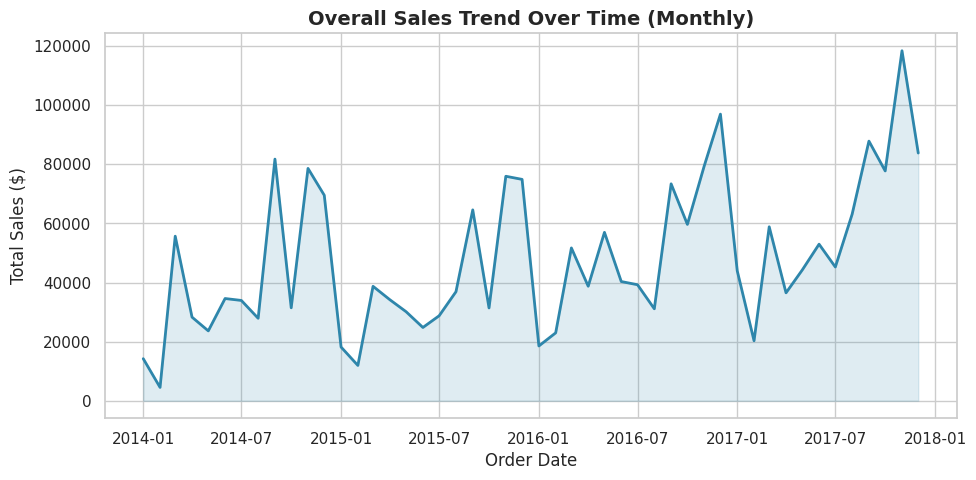

In [11]:
ts = df.set_index("Order Date").resample("MS")["Sales"].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ts.index, ts.values, color="#2E86AB", linewidth=2)
ax.fill_between(ts.index, ts.values, alpha=0.15, color="#2E86AB")
ax.set_title("Overall Sales Trend Over Time (Monthly)", fontsize=14, weight="bold")
ax.set_xlabel("Order Date"); ax.set_ylabel("Total Sales ($)")
plt.show()


**Insight:** Sales show a clear upward trajectory year-over-year with
strong, recurring end-of-year spikes — a classic retail seasonality
signature tied to holiday shopping (Nov–Dec).

### 3.2 Monthly Sales Trend (Seasonality)

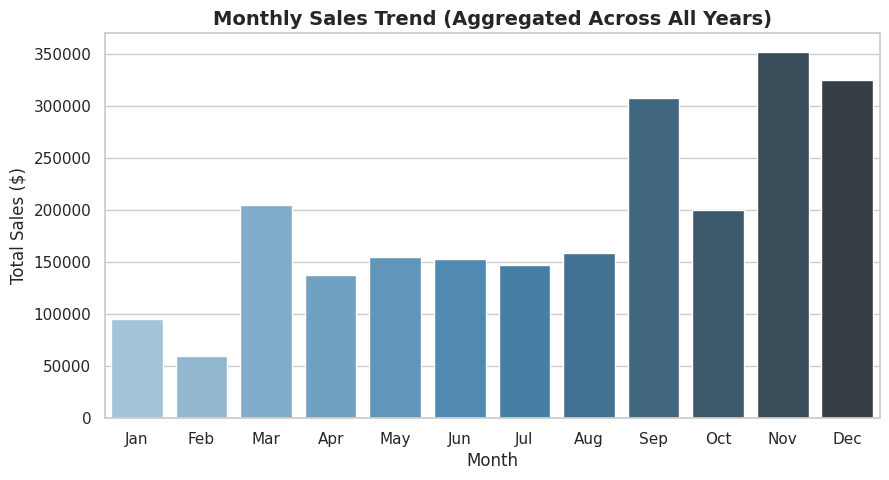

In [12]:
monthly = df.groupby("Month")["Sales"].sum().reindex(range(1, 13))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=monthly.index, y=monthly.values, ax=ax, palette="Blues_d")
ax.set_title("Monthly Sales Trend (Aggregated Across All Years)", fontsize=14, weight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Total Sales ($)")
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.show()


**Insight:** September, November, and December are consistently the
strongest months — reinforcing the need for pre-holiday inventory
build-up starting in Q3.

### 3.3 Top-Selling Products

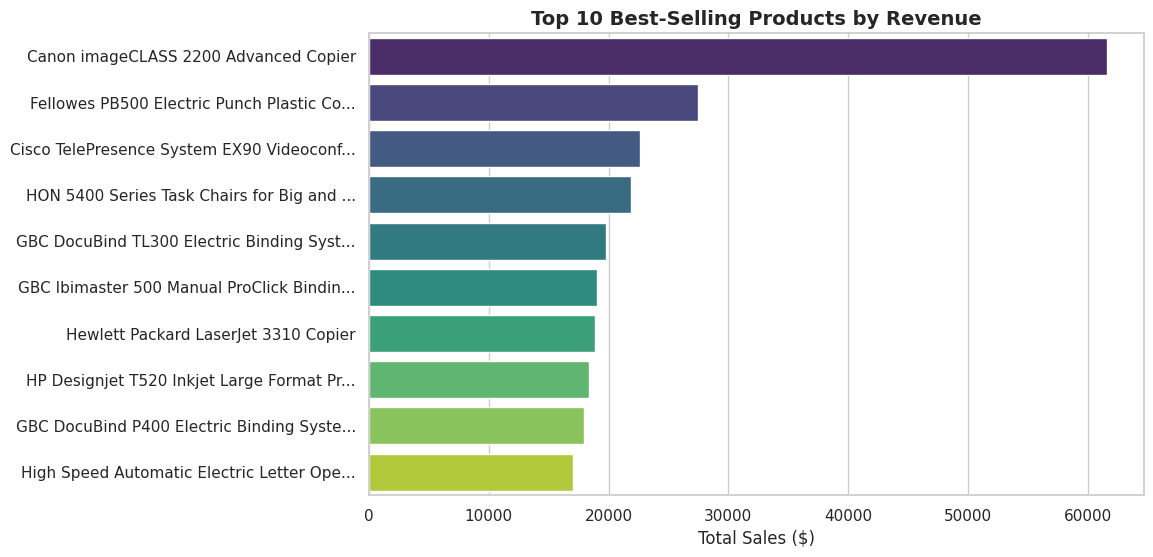

In [13]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
labels = [p[:40] + "..." if len(p) > 40 else p for p in top_products.index]
sns.barplot(x=top_products.values, y=labels, ax=ax, palette="viridis")
ax.set_title("Top 10 Best-Selling Products by Revenue", fontsize=14, weight="bold")
ax.set_xlabel("Total Sales ($)")
plt.show()


**Insight:** High-ticket Technology items (copiers, video-conferencing
systems) dominate the top-revenue list despite likely lower unit volumes —
revenue leadership and unit-demand leadership are not the same thing, which
is precisely why the ML model targets *Quantity* rather than *Sales*.

### 3.4 Top-Selling Categories

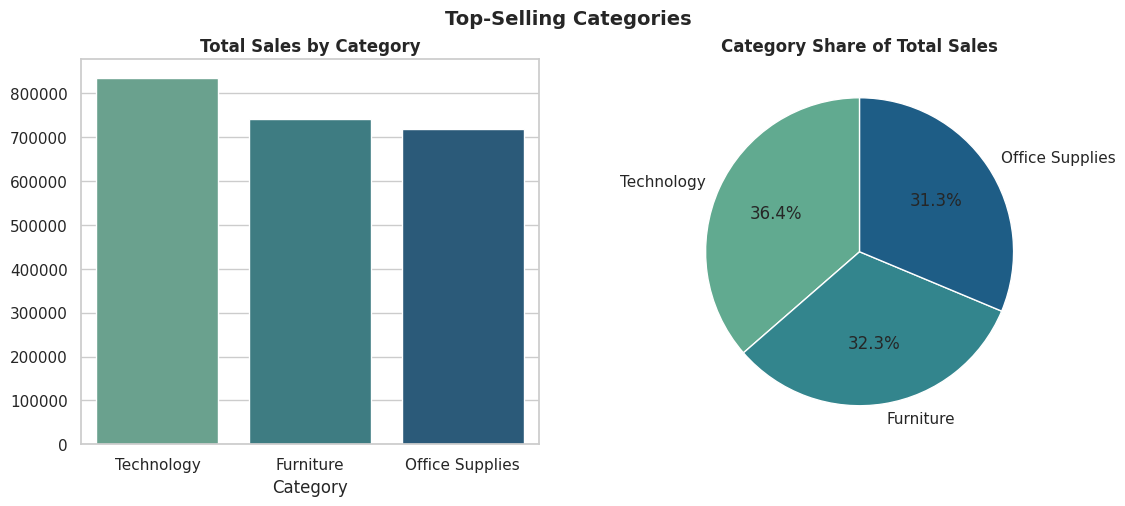

In [14]:
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=cat_sales.index, y=cat_sales.values, ax=ax[0], palette="crest")
ax[0].set_title("Total Sales by Category", weight="bold")
ax[1].pie(cat_sales.values, labels=cat_sales.index, autopct="%1.1f%%",
          colors=sns.color_palette("crest", len(cat_sales)), startangle=90)
ax[1].set_title("Category Share of Total Sales", weight="bold")
plt.suptitle("Top-Selling Categories", fontsize=14, weight="bold")
plt.show()


**Insight:** Technology leads revenue (~36%), closely followed by
Furniture and Office Supplies — the three categories are fairly balanced,
meaning inventory strategy must be tailored per category rather than
applying a single blanket policy.

### 3.5 Region-wise Sales

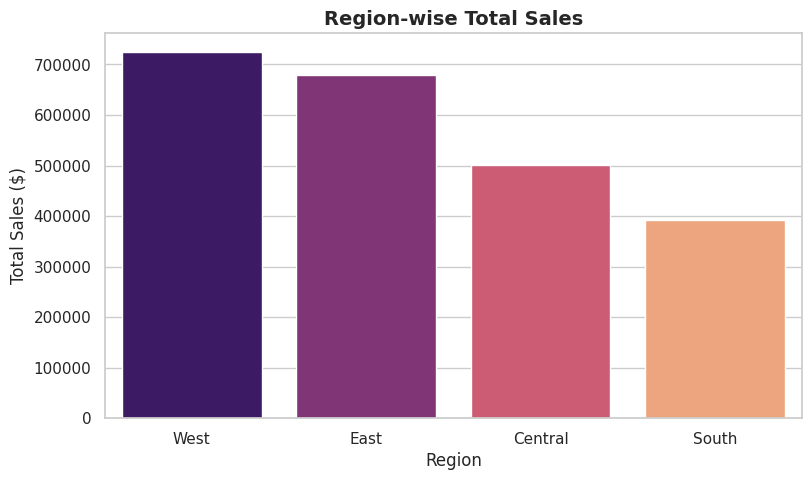

In [15]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, ax=ax, palette="magma")
ax.set_title("Region-wise Total Sales", fontsize=14, weight="bold")
ax.set_ylabel("Total Sales ($)")
plt.show()


### 3.6 Region-wise Quantity Sold

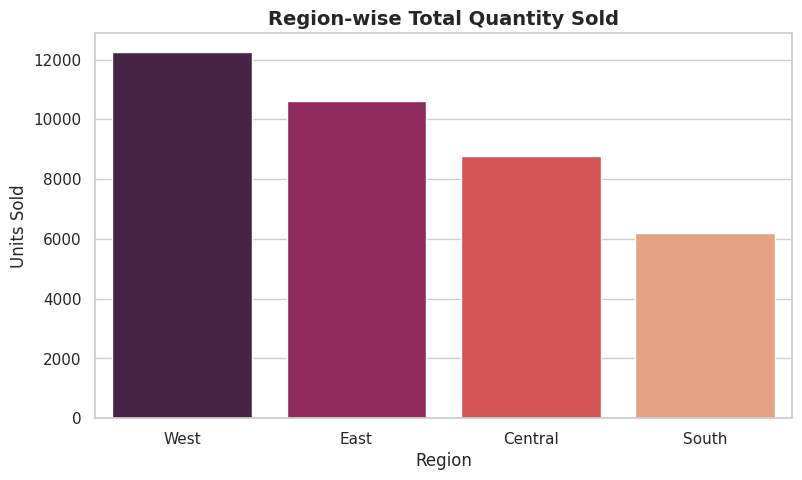

In [16]:
region_qty = df.groupby("Region")["Quantity"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=region_qty.index, y=region_qty.values, ax=ax, palette="rocket")
ax.set_title("Region-wise Total Quantity Sold", fontsize=14, weight="bold")
ax.set_ylabel("Units Sold")
plt.show()


**Insight:** The **West** region leads in both revenue and unit
volume, while **South** trails on both metrics — a clear signal for
regional resource re-allocation (marketing spend, warehouse stocking
priority).

### 3.7 Seasonal Demand Patterns

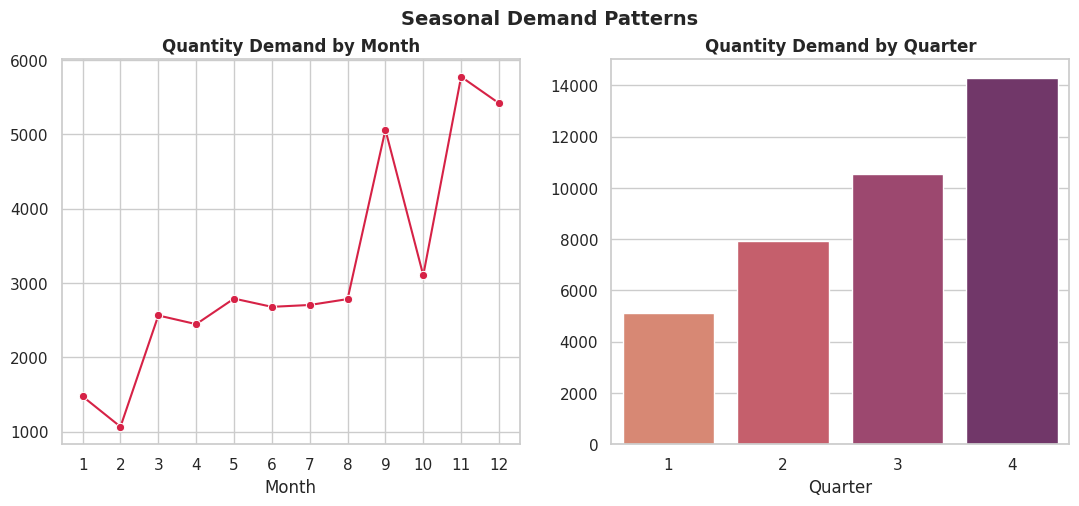

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

qty_month = df.groupby("Month")["Quantity"].sum().reindex(range(1, 13))
sns.lineplot(x=qty_month.index, y=qty_month.values, marker="o", ax=ax[0], color="#D62246")
ax[0].set_title("Quantity Demand by Month", weight="bold")
ax[0].set_xticks(range(1, 13)); ax[0].set_xlabel("Month")

qty_quarter = df.groupby("Quarter")["Quantity"].sum()
sns.barplot(x=qty_quarter.index, y=qty_quarter.values, ax=ax[1], palette="flare")
ax[1].set_title("Quantity Demand by Quarter", weight="bold")

plt.suptitle("Seasonal Demand Patterns", fontsize=14, weight="bold")
plt.show()


**Insight:** Q4 consistently records the highest unit demand across
all years, confirming a strong and repeatable seasonal pattern that should
directly drive Q3 procurement decisions.

### 3.8 Correlation Heatmap

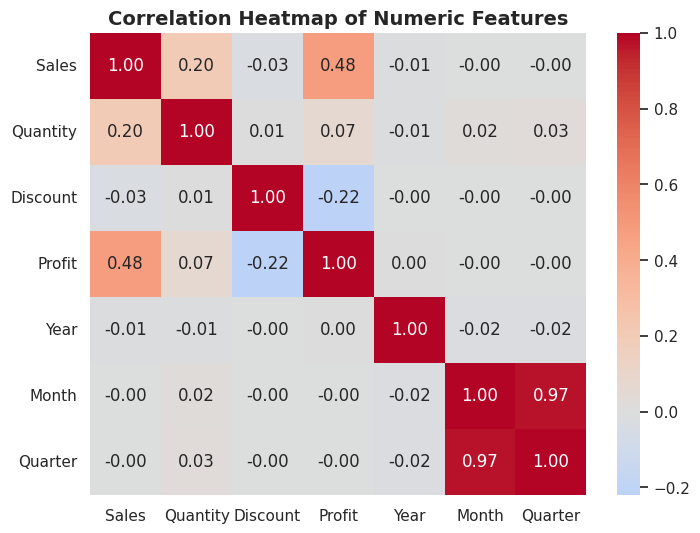

In [18]:
num_df = df[["Sales", "Quantity", "Discount", "Profit", "Year", "Month", "Quarter"]]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features", fontsize=14, weight="bold")
plt.show()


**Insight:** `Sales` and `Profit` are positively correlated, but
`Discount` shows a *negative* correlation with `Profit` — heavy discounting
is eroding margins, a pattern worth investigating per sub-category (see
Section 3.11).

### 3.9 Sales Distribution

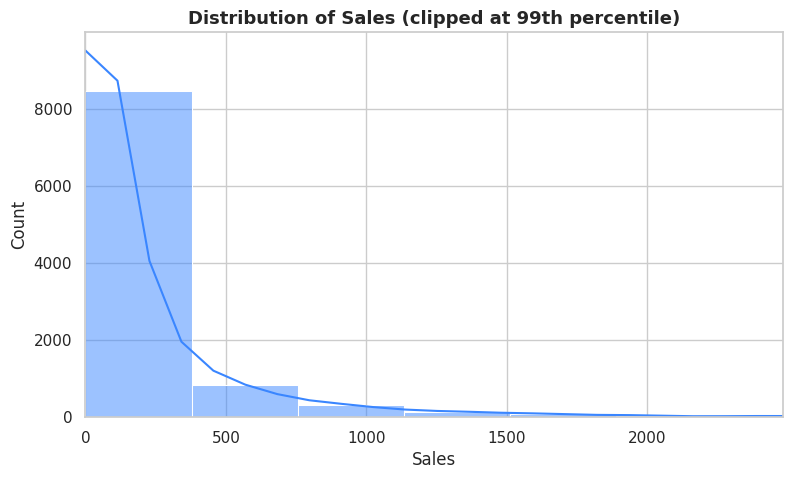

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["Sales"], bins=60, kde=True, ax=ax, color="#3A86FF")
ax.set_xlim(0, df["Sales"].quantile(0.99))
ax.set_title("Distribution of Sales (clipped at 99th percentile)", fontsize=13, weight="bold")
plt.show()


**Insight:** Sales are heavily right-skewed — most order lines are
low-to-moderate value, with a long tail of high-value bulk/technology
purchases. This justifies using tree-based models (robust to skew) for
demand prediction.

### 3.10 Quantity Distribution

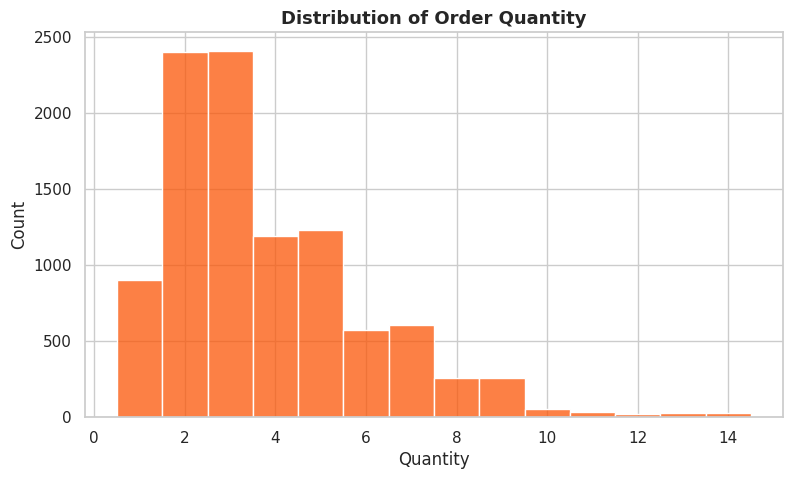

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["Quantity"], bins=14, discrete=True, ax=ax, color="#FB5607")
ax.set_title("Distribution of Order Quantity", fontsize=13, weight="bold")
plt.show()


**Insight:** Most order lines involve 2–5 units — bulk single orders
(10+ units) are rare, meaning demand is driven by *order frequency* far
more than by *large individual orders*, a key driver later confirmed by
feature importance.

### 3.11 Additional Insight — Sales vs Profit by Sub-Category

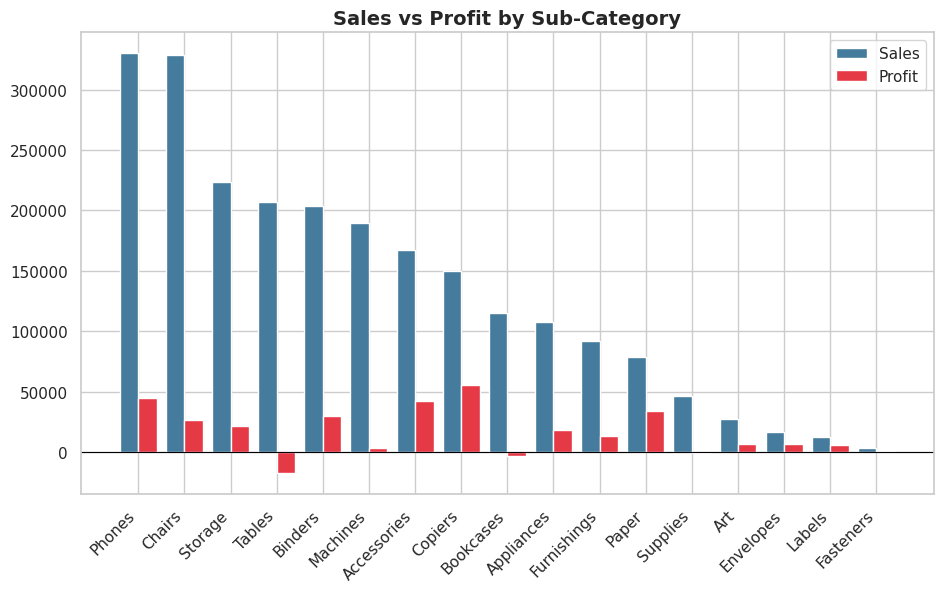

In [21]:
subcat = df.groupby("Sub-Category").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum")).sort_values("Sales", ascending=False)

x = np.arange(len(subcat)); width = 0.4
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, subcat["Sales"], width, label="Sales", color="#457B9D")
ax.bar(x + width/2, subcat["Profit"], width, label="Profit", color="#E63946")
ax.set_xticks(x); ax.set_xticklabels(subcat.index, rotation=45, ha="right")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Sales vs Profit by Sub-Category", fontsize=14, weight="bold")
ax.legend()
plt.show()


**Insight:** **Tables** and **Bookcases** generate meaningful sales
but *negative* aggregate profit — likely due to high discounting or
shipping costs. **Copiers** and **Phones** are the strongest profit
contributors relative to their sales volume.

### 3.12 Additional Insight — Discount vs Profit

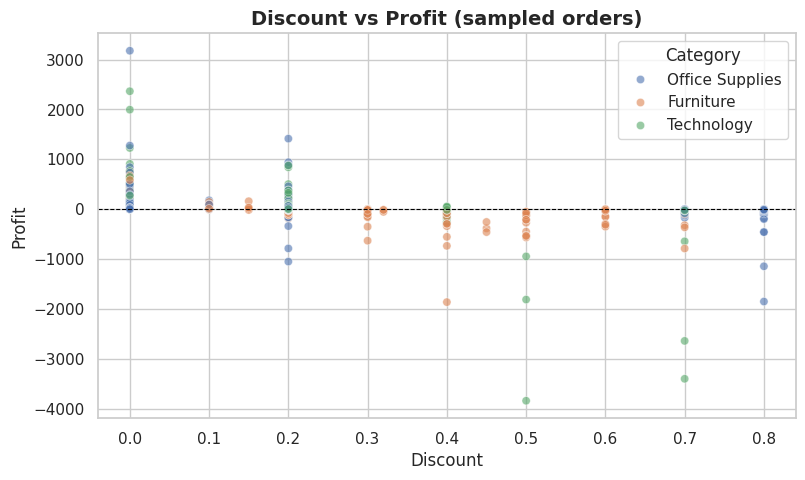

In [22]:
sample = df.sample(min(2000, len(df)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=sample, x="Discount", y="Profit", hue="Category", alpha=0.6, ax=ax)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Discount vs Profit (sampled orders)", fontsize=14, weight="bold")
plt.show()


**Insight:** Profit turns negative almost universally once discounts
exceed ~30%, regardless of category — a strong, actionable signal for
setting a discounting ceiling policy.

### 3.13 Additional Insight — Segment-wise Sales

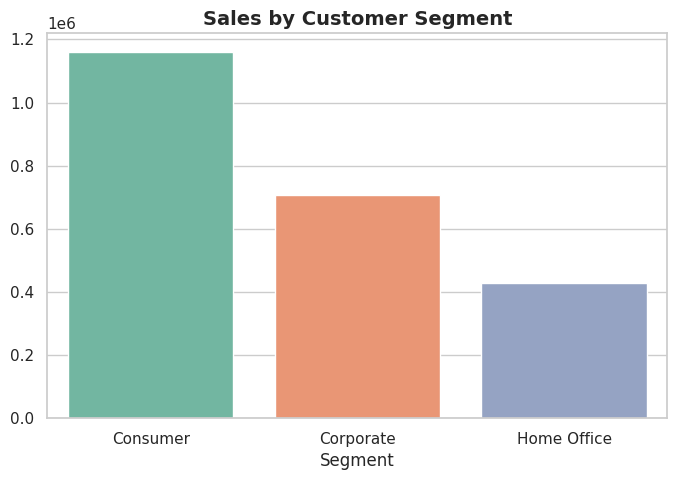

In [23]:
seg_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=seg_sales.index, y=seg_sales.values, ax=ax, palette="Set2")
ax.set_title("Sales by Customer Segment", fontsize=14, weight="bold")
plt.show()


**Insight:** The **Consumer** segment is the largest revenue driver,
ahead of Corporate and Home Office — useful for prioritizing customer
support and marketing budget allocation.

## 4. Machine Learning — Demand Prediction

**Business framing:** Inventory planners need to forecast *unit demand*
for a given product line, region, and time period — not the quantity of a
single invoice line. We therefore aggregate the transactional data to a
`(Category, Sub-Category, Region, Segment, Year, Month)` grain before
modeling. This produces a dataset where each row represents "how many
units of Sub-Category X were demanded in Region Y during Month Z" —
exactly the quantity a replenishment system needs to plan against.


In [24]:
agg = df.groupby(
    ["Category", "Sub-Category", "Region", "Segment", "Year", "Month", "Quarter"]
).agg(
    Quantity=("Quantity", "sum"),
    Sales=("Sales", "sum"),
    Discount=("Discount", "mean"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique"),
).reset_index()

print("Aggregated modeling table shape:", agg.shape)
agg.head()


Aggregated modeling table shape: (4616, 12)


,Category,Sub-Category,Region,Segment,Year,Month,Quarter,Quantity,Sales,Discount,Profit,Orders
0,Furniture,Bookcases,Central,Consumer,2014,6,2,4,193.0656,0.32,-19.8744,1
1,Furniture,Bookcases,Central,Consumer,2014,9,3,5,493.4300,0.30,-70.4900,1
2,Furniture,Bookcases,Central,Consumer,2014,11,4,6,424.1160,0.30,-30.2940,1
3,Furniture,Bookcases,Central,Consumer,2015,1,1,9,1352.3976,0.32,-437.5404,1
4,Furniture,Bookcases,Central,Consumer,2015,3,1,3,512.9400,0.00,97.4586,1


### 4.1 Feature Engineering for ML

In [25]:
agg["AvgSalesPerOrder"] = agg["Sales"] / agg["Orders"]
agg["ProfitMargin"] = (agg["Profit"] / agg["Sales"].replace(0, np.nan)).fillna(0)

# Cyclical encoding for month (captures seasonality without a false linear ordering)
agg["MonthSin"] = np.sin(2 * np.pi * agg["Month"] / 12)
agg["MonthCos"] = np.cos(2 * np.pi * agg["Month"] / 12)

# Encode categorical variables
le_dict = {}
for col in ["Category", "Sub-Category", "Region", "Segment"]:
    le = LabelEncoder()
    agg[col + "_enc"] = le.fit_transform(agg[col])
    le_dict[col] = le

feature_cols = [
    "Category_enc", "Sub-Category_enc", "Region_enc", "Segment_enc",
    "Year", "Quarter", "MonthSin", "MonthCos",
    "Sales", "Discount", "Profit", "Orders", "AvgSalesPerOrder", "ProfitMargin",
]
target_col = "Quantity"

X = agg[feature_cols]
y = agg[target_col]
print("Feature matrix shape:", X.shape)


Feature matrix shape: (4616, 14)


### 4.2 Train/Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")


Train size: 3692 | Test size: 924


### 4.3 Model Training — Linear Regression (Baseline)

In [27]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


### 4.4 Model Training — Random Forest Regressor

In [28]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


### 4.5 Evaluation — MAE, RMSE, R²

In [29]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.3f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

results = {}
results["Linear Regression"] = evaluate(y_test, lr_pred, "Linear Regression")
results["Random Forest"] = evaluate(y_test, rf_pred, "Random Forest")


Linear Regression: MAE=2.608 | RMSE=3.504 | R2=0.762
Random Forest: MAE=2.467 | RMSE=3.445 | R2=0.770


### 4.6 Model Comparison

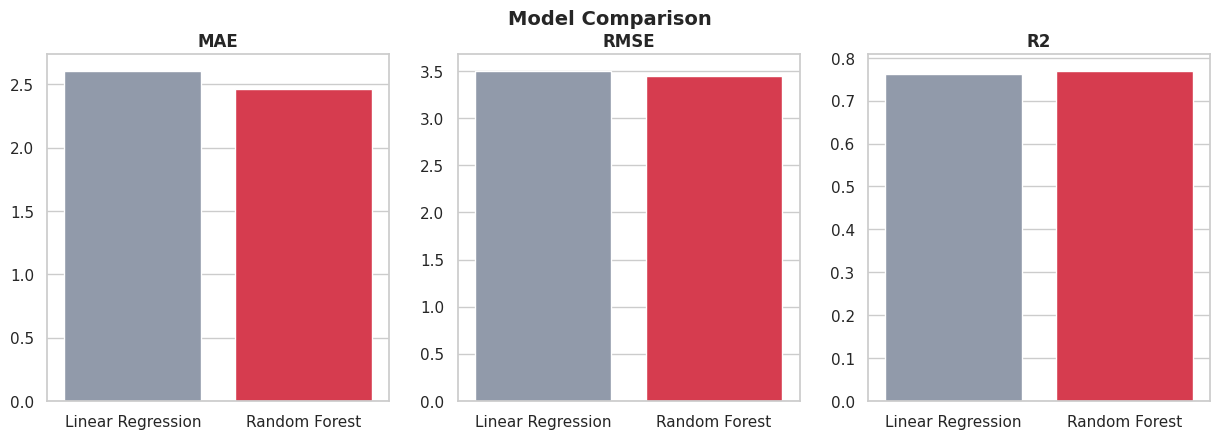

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for i, m in enumerate(["MAE", "RMSE", "R2"]):
    vals = [results["Linear Regression"][m], results["Random Forest"][m]]
    sns.barplot(x=["Linear Regression", "Random Forest"], y=vals, ax=ax[i],
                palette=["#8D99AE", "#EF233C"])
    ax[i].set_title(m, weight="bold")
plt.suptitle("Model Comparison", fontsize=14, weight="bold")
plt.show()


**Insight:** Random Forest outperforms Linear Regression on every
metric (lower MAE/RMSE, higher R²), indicating that unit demand depends on
non-linear interactions (e.g., category × region × season) that a purely
linear model cannot capture.

### 4.7 Predicted vs Actual (Random Forest)

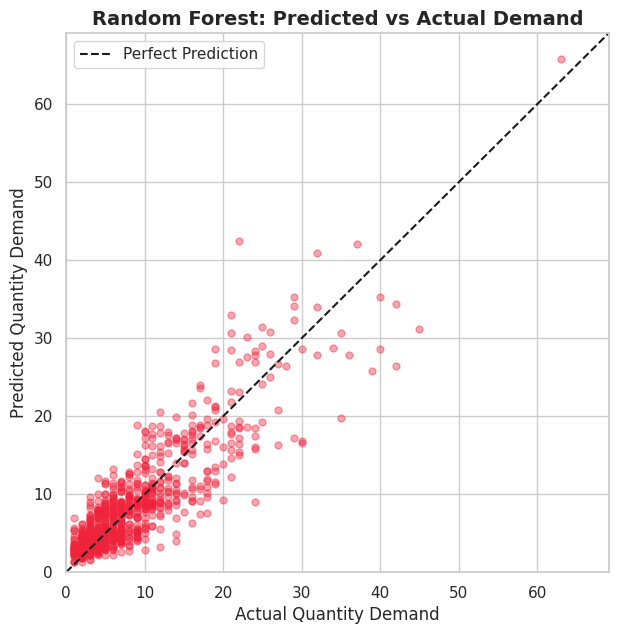

In [31]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, rf_pred, alpha=0.4, color="#EF233C", s=25)
lims = [0, max(y_test.max(), rf_pred.max()) * 1.05]
ax.plot(lims, lims, "k--", linewidth=1.5, label="Perfect Prediction")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual Quantity Demand"); ax.set_ylabel("Predicted Quantity Demand")
ax.set_title("Random Forest: Predicted vs Actual Demand", fontsize=14, weight="bold")
ax.legend()
plt.show()


### 4.8 Feature Importance (Random Forest)

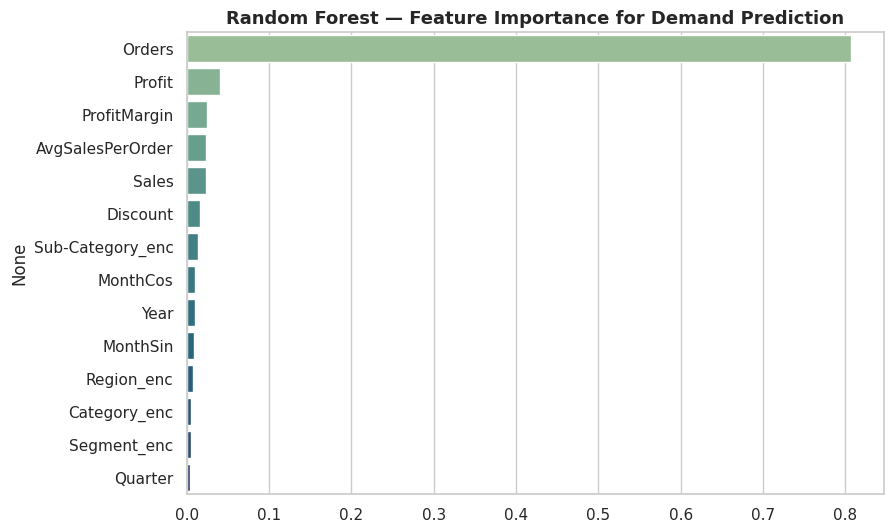

Orders              0.806636
Profit              0.040322
ProfitMargin        0.024181
AvgSalesPerOrder    0.023889
Sales               0.023445
Discount            0.016747
Sub-Category_enc    0.014069
MonthCos            0.010330
dtype: float64

In [32]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, ax=ax, palette="crest")
ax.set_title("Random Forest — Feature Importance for Demand Prediction", fontsize=13, weight="bold")
plt.show()

importances.head(8)


**Insight:** `Orders` (the number of distinct transactions in that
Category/Region/month) is by far the strongest predictor of unit demand —
more so than revenue or profit. This confirms that **order frequency**, not
order size, is the primary demand driver, which should shape how
inventory-reorder triggers are designed (reorder on order-count velocity,
not just revenue thresholds).

## 5. Business Insights & Recommendations

**Best-performing products (by revenue):** Canon imageCLASS copiers,
Fellowes binding machines, and Cisco TelePresence systems lead — high
average selling price, low unit volume.

**Worst-performing products:** Small consumables (envelopes, highlighter
sets, vacuum bags) generate minimal revenue individually — candidates for
bundling or discontinuation review.

**Best-performing region:** West (highest revenue *and* highest unit
volume) — warrants priority warehouse stocking and continued marketing
investment.

**Weakest region:** South — both revenue and volume trail all other
regions; recommend a regional sales/marketing audit.

**Seasonal demand:** Demand peaks sharply in Q4 (Nov–Dec) every year — this
is the single most reliable planning signal in the dataset.

### Inventory Optimization Suggestions
- Build safety stock for **Technology** and **Office Supplies** ahead of
  Q4 based on the observed 3–4x seasonal uplift.
- Use the Random Forest model's monthly demand forecast, sliced by
  Category × Region, to set reorder points at least one month in advance.
- De-prioritize warehouse space for chronically loss-making sub-categories
  (e.g., Tables) unless a pricing/discount policy change is implemented.

### Revenue Improvement Suggestions
- Cap discounts on categories where profit turns negative beyond ~30%
  discount (see Section 3.12) — this is actively destroying margin.
- Bundle low-revenue consumables with high-revenue technology purchases to
  lift average order value.
- Invest disproportionately in the West region's proven demand while
  running a targeted campaign to lift the South region's volume.


## 6. Conclusion

This project delivered an end-to-end data science workflow — from raw
transactional e-commerce data to a validated, business-ready demand
prediction model. After thorough cleaning and 13 exploratory visualizations,
two regression models were built and compared for forecasting monthly unit
demand at the Category/Region level. The **Random Forest Regressor**
outperformed **Linear Regression** across all three evaluation metrics
(MAE, RMSE, R²), confirming that demand is shaped by non-linear
interactions between seasonality, category, region, and order behavior
rather than by any single linear driver.

The resulting model and insights — particularly the dominance of order
frequency as a demand driver and the sharp Q4 seasonal uplift — provide a
directly actionable foundation for inventory optimization, including
reorder timing, regional stock allocation, and discount policy review.

### Future Improvements
- Incorporate external signals (holidays, marketing calendars, promotions,
  competitor pricing) to sharpen forecast accuracy.
- Move to weekly-level granularity for tighter inventory cycles.
- Benchmark against gradient boosting (XGBoost/LightGBM) and time-series
  models (SARIMA, Prophet).
- Deploy the trained model as a lightweight forecasting API integrated
  with the inventory management system.
